Import libraries

In [ ]:
import os
import pathlib
import random
import json
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
Download dataset

In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"sadanijayarathna","key":"ea1a9b7cf6fa3198b8fd7b537976c801"}'}

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!mkdir -p /content/datasets
!kaggle datasets download -d kaustubhb999/tomatoleaf -p /content/datasets --unzip

Dataset URL: https://www.kaggle.com/datasets/kaustubhb999/tomatoleaf
License(s): CC0-1.0
100% 179M/179M [00:12<00:00, 15.5MB/s]



In [ ]:
!find /content/datasets -maxdepth 4 -type d

/content/datasets
/content/datasets/tomato
/content/datasets/tomato/val
/content/datasets/tomato/val/Tomato___Bacterial_spot
/content/datasets/tomato/val/Tomato___Early_blight
/content/datasets/tomato/val/Tomato___Leaf_Mold
/content/datasets/tomato/val/Tomato___Tomato_Yellow_Leaf_Curl_Virus
/content/datasets/tomato/val/Tomato___healthy
/content/datasets/tomato/val/Tomato___Spider_mites Two-spotted_spider_mite
/content/datasets/tomato/val/Tomato___Late_blight
/content/datasets/tomato/val/Tomato___Septoria_leaf_spot
/content/datasets/tomato/val/Tomato___Tomato_mosaic_virus
/content/datasets/tomato/val/Tomato___Target_Spot
/content/datasets/tomato/train
/content/datasets/tomato/train/Tomato___Bacterial_spot
/content/datasets/tomato/train/Tomato___Early_blight
/content/datasets/tomato/train/Tomato___Leaf_Mold
/content/datasets/tomato/train/Tomato___Tomato_Yellow_Leaf_Curl_Virus
/content/datasets/tomato/train/Tomato___healthy
/content/datasets/tomato/train/Tomato___Spider_mites Two-spotted_

In [ ]:
train_dir = "/content/datasets/tomato/train"
test_dir = "/content/datasets/tomato/val"

print("Train exists:", os.path.exists(train_dir))
print("Test exists:", os.path.exists(test_dir))

Train exists: True
Test exists: True


In [ ]:
train_path = pathlib.Path(train_dir)

class_names = sorted([item.name for item in train_path.glob("*") if item.is_dir()])
num_classes = len(class_names)

print("Number of classes:", num_classes)
print("Class names:")
for i, name in enumerate(class_names):
    print(i, name)

Number of classes: 10
Class names:
0 Tomato___Bacterial_spot
1 Tomato___Early_blight
2 Tomato___Late_blight
3 Tomato___Leaf_Mold
4 Tomato___Septoria_leaf_spot
5 Tomato___Spider_mites Two-spotted_spider_mite
6 Tomato___Target_Spot
7 Tomato___Tomato_Yellow_Leaf_Curl_Virus
8 Tomato___Tomato_mosaic_virus
9 Tomato___healthy


In [ ]:
image_paths = []
image_labels = []

for label_index, class_name in enumerate(class_names):
    class_folder = train_path / class_name

    for image_file in class_folder.glob("*"):
        image_paths.append(str(image_file))
        image_labels.append(label_index)

image_paths = np.array(image_paths)
image_labels = np.array(image_labels)

print("Total training images:", len(image_paths))
print("Total labels:", len(image_labels))

Total training images: 10000
Total labels: 10000


Shuffle dataset

In [ ]:
SEED = 123
np.random.seed(SEED)

indices = np.arange(len(image_paths))
np.random.shuffle(indices)

image_paths = image_paths[indices]
image_labels = image_labels[indices]

Split into training and validation data

In [ ]:
val_ratio = 0.15
val_size = int(len(image_paths) * val_ratio)

val_paths = image_paths[:val_size]
val_labels = image_labels[:val_size]

fl_train_paths = image_paths[val_size:]
fl_train_labels = image_labels[val_size:]

print("Federated training images:", len(fl_train_paths))
print("Validation images:", len(val_paths))

Federated training images: 8500
Validation images: 1500


Split training data into clients

In [ ]:
NUM_CLIENTS = 4

client_paths = np.array_split(fl_train_paths, NUM_CLIENTS)
client_labels = np.array_split(fl_train_labels, NUM_CLIENTS)

for i in range(NUM_CLIENTS):
    print(f"Client {i+1} images:", len(client_paths[i]))

Client 1 images: 2125
Client 2 images: 2125
Client 3 images: 2125
Client 4 images: 2125


Create preprocessing function

In [ ]:
IMG_SIZE = 128
BATCH_SIZE = 32

def load_and_preprocess_image(file_path, label):
    image = tf.io.read_file(file_path)
    image = tf.image.decode_image(image, channels=3, expand_animations=False)
    image.set_shape([None, None, 3])
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

Create TensorFlow datasets

In [ ]:
def create_dataset(paths, labels, shuffle=True):
    dataset = tf.data.Dataset.from_tensor_slices((paths, labels))
    dataset = dataset.map(load_and_preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)

    if shuffle:
        dataset = dataset.shuffle(1000)

    dataset = dataset.batch(BATCH_SIZE)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)

    return dataset

client_datasets = []

for i in range(NUM_CLIENTS):
    ds = create_dataset(client_paths[i], client_labels[i], shuffle=True)
    client_datasets.append(ds)

val_ds = create_dataset(val_paths, val_labels, shuffle=False)

Create test dataset

In [ ]:
test_path = pathlib.Path(test_dir)

test_image_paths = []
test_image_labels = []

for label_index, class_name in enumerate(class_names):
    class_folder = test_path / class_name

    for image_file in class_folder.glob("*"):
        test_image_paths.append(str(image_file))
        test_image_labels.append(label_index)

test_image_paths = np.array(test_image_paths)
test_image_labels = np.array(test_image_labels)

test_ds = create_dataset(test_image_paths, test_image_labels, shuffle=False)

print("Test images:", len(test_image_paths))

Test images: 1000


Create CNN model function

In [ ]:
def create_cnn_model():
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),

        tf.keras.layers.Conv2D(32, (3, 3), activation='relu'),
        tf.keras.layers.MaxPooling2D(2, 2),

        tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
        tf.keras.layers.MaxPooling2D(2, 2),

        tf.keras.layers.Conv2D(128, (3, 3), activation='relu'),
        tf.keras.layers.MaxPooling2D(2, 2),

        tf.keras.layers.Flatten(),

        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dropout(0.3),

        tf.keras.layers.Dense(num_classes, activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

Create global model

In [ ]:
global_model = create_cnn_model()
global_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,930 (12.61 MB)

 Trainable params: 3,305,930 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
def average_weights(local_weights):
    averaged_weights = []

    for weights in zip(*local_weights):
        averaged_layer = np.mean(np.stack(weights, axis=0), axis=0)
        averaged_weights.append(averaged_layer)

    return averaged_weights

Train using Federated Learning

In [ ]:
NUM_ROUNDS = 5
LOCAL_EPOCHS = 1

round_accuracies = []
round_losses = []

for round_num in range(NUM_ROUNDS):
    print(f"\nFederated Round {round_num + 1}/{NUM_ROUNDS}")

    local_weights = []

    for client_id in range(NUM_CLIENTS):
        print(f"Training Client {client_id + 1}")

        local_model = create_cnn_model()

        # Send global model weights to client
        local_model.set_weights(global_model.get_weights())

        # Train locally on client's own data
        local_model.fit(
            client_datasets[client_id],
            epochs=LOCAL_EPOCHS,
            verbose=0
        )

        # Collect only model weights
        local_weights.append(local_model.get_weights())

    # Server averages client weights
    new_global_weights = average_weights(local_weights)

    # Update global model
    global_model.set_weights(new_global_weights)

    # Evaluate global model on validation data
    val_loss, val_accuracy = global_model.evaluate(val_ds, verbose=0)

    round_losses.append(val_loss)
    round_accuracies.append(val_accuracy)

    print(f"Validation Loss: {val_loss:.4f}")
    print(f"Validation Accuracy: {val_accuracy:.4f}")


Federated Round 1/5
Training Client 1
Training Client 2
Training Client 3
Training Client 4
Validation Loss: 2.1282
Validation Accuracy: 0.4847

Federated Round 2/5
Training Client 1
Training Client 2
Training Client 3
Training Client 4
Validation Loss: 1.1036
Validation Accuracy: 0.6440

Federated Round 3/5
Training Client 1
Training Client 2
Training Client 3
Training Client 4
Validation Loss: 0.7727
Validation Accuracy: 0.7420

Federated Round 4/5
Training Client 1
Training Client 2
Training Client 3
Training Client 4
Validation Loss: 0.6829
Validation Accuracy: 0.7693

Federated Round 5/5
Training Client 1
Training Client 2
Training Client 3
Training Client 4
Validation Loss: 0.5902
Validation Accuracy: 0.8033


Plot federated learning accuracy

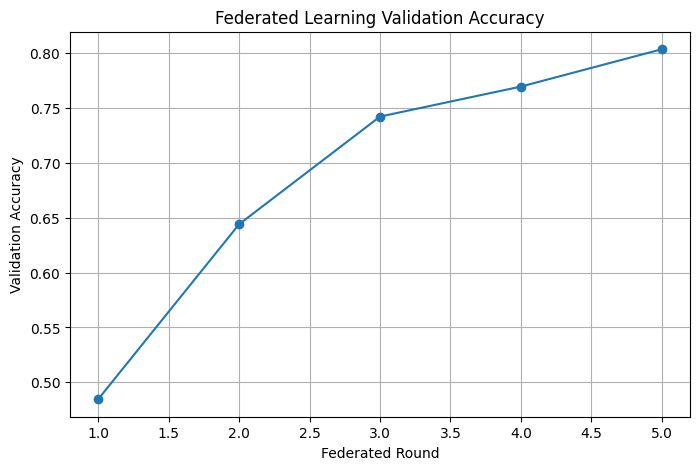

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, NUM_ROUNDS + 1), round_accuracies, marker='o')
plt.xlabel("Federated Round")
plt.ylabel("Validation Accuracy")
plt.title("Federated Learning Validation Accuracy")
plt.grid(True)
plt.show()

Plot federated learning loss

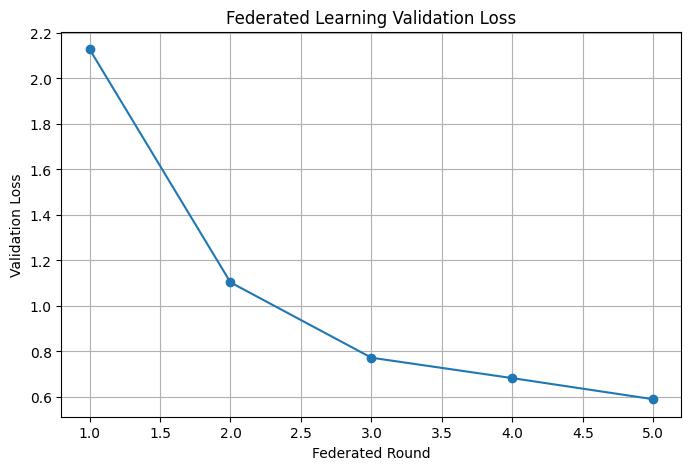

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, NUM_ROUNDS + 1), round_losses, marker='o')
plt.xlabel("Federated Round")
plt.ylabel("Validation Loss")
plt.title("Federated Learning Validation Loss")
plt.grid(True)
plt.show()

Evaluate final federated model

In [ ]:
test_loss, test_accuracy = global_model.evaluate(test_ds)

print("Federated Model Test Loss:", test_loss)
print("Federated Model Test Accuracy:", test_accuracy)

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - accuracy: 0.7980 - loss: 0.6215
Federated Model Test Loss: 0.6215177178382874
Federated Model Test Accuracy: 0.7979999780654907


Calculate precision, recall, F1-score

In [ ]:
y_true = []
y_pred = []

for images, labels in test_ds:
    predictions = global_model.predict(images)
    predicted_labels = np.argmax(predictions, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_labels)

accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_true, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)

print("Final Federated Learning Evaluation")
print("-----------------------------------")
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1-score :", f1)

print("\nDetailed Classification Report")
print(classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    zero_division=0
))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 395ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━

Confusion matrix

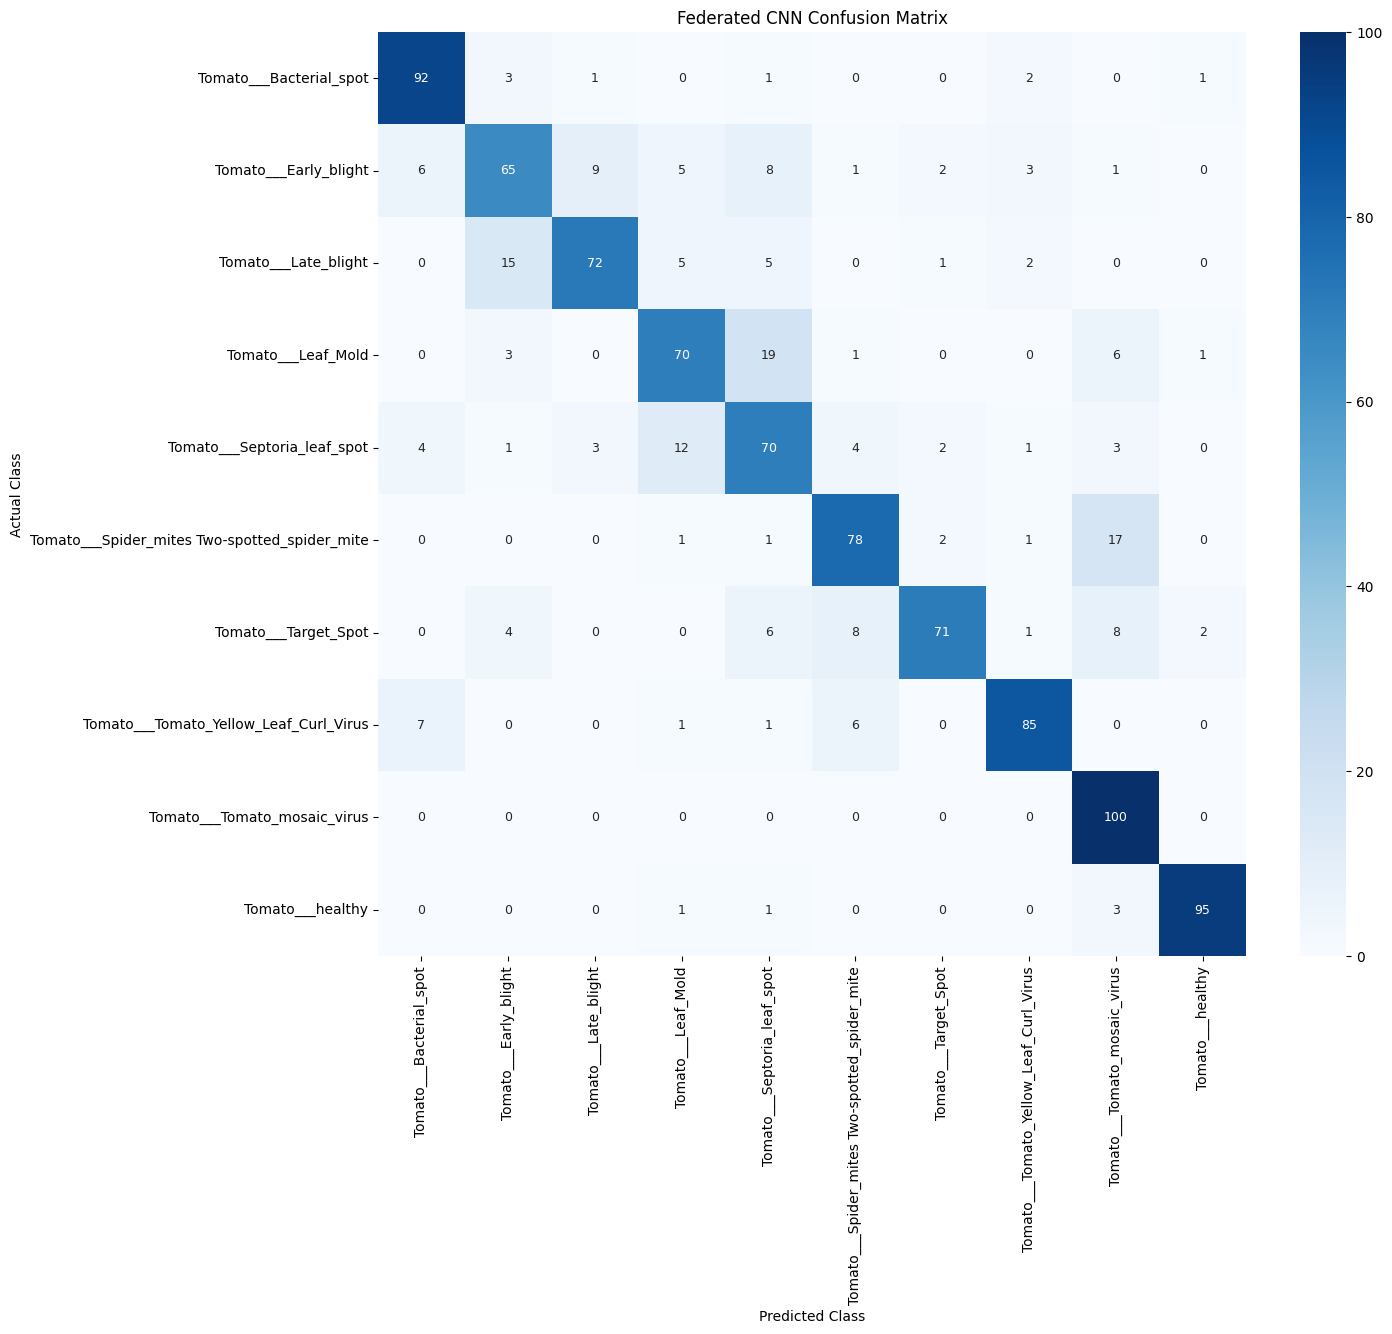

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(14, 12))

sns.heatmap(
    cm,
    annot=True,          # show numbers
    fmt='d',             # integer format
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names,
    annot_kws={"size": 9}
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("Federated CNN Confusion Matrix")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.show()

In [ ]:
save_dir = "/content/drive/MyDrive/AgriMind_Phase2"
os.makedirs(save_dir, exist_ok=True)

global_model.save("/content/drive/MyDrive/AgriMind_Phase2/agrimind_federated_cnn_model.h5")

with open("/content/drive/MyDrive/AgriMind_Phase2/class_names.json", "w") as f:
    json.dump(class_names, f)

print("Federated CNN model and class names saved successfully!")

Federated CNN model and class names saved successfully!


In [ ]:
loaded_federated_model = tf.keras.models.load_model(
    "/content/drive/MyDrive/AgriMind_Phase2/agrimind_federated_cnn_model.h5"
)

print("Federated model loaded successfully!")

Federated model loaded successfully!


In [ ]:
loaded_test_loss, loaded_test_accuracy = loaded_federated_model.evaluate(test_ds)

print("Loaded Federated Model Test Loss:", loaded_test_loss)
print("Loaded Federated Model Test Accuracy:", loaded_test_accuracy)

32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 53ms/step - accuracy: 0.7980 - loss: 0.6215
Loaded Federated Model Test Loss: 0.6215177178382874
Loaded Federated Model Test Accuracy: 0.7979999780654907


For loaded federated model

In [ ]:
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

y_true = []
y_pred = []

for images, labels in test_ds:
    predictions = loaded_federated_model.predict(images)
    predicted_labels = np.argmax(predictions, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_labels)

fed_accuracy = accuracy_score(y_true, y_pred)
fed_precision = precision_score(y_true, y_pred, average='weighted', zero_division=0)
fed_recall = recall_score(y_true, y_pred, average='weighted', zero_division=0)
fed_f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)

print("Federated CNN Final Evaluation")
print("------------------------------")
print("Accuracy :", fed_accuracy)
print("Precision:", fed_precision)
print("Recall   :", fed_recall)
print("F1-score :", fed_f1)

print("\nDetailed Classification Report")
print(classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    zero_division=0
))

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
1/1 ━━━━━━━

Comparison table

In [ ]:
import pandas as pd

comparison_data = {
    "Model": ["Centralized CNN", "Federated CNN"],
    "Accuracy": [0.866, fed_accuracy],
    "Precision": [0.877, fed_precision],
    "Recall": [0.866, fed_recall],
    "F1-score": [0.866, fed_f1]
}

comparison_df = pd.DataFrame(comparison_data)
comparison_df

,Model,Accuracy,Precision,Recall,F1-score
0,Centralized CNN,0.866,0.877000,0.866,0.866000
1,Federated CNN,0.798,0.805237,0.798,0.797025


In [ ]:
comparison_df.to_csv(
    "/content/drive/MyDrive/AgriMind_Phase2/centralized_vs_federated_comparison.csv",
    index=False
)

print("Comparison table saved successfully!")

Comparison table saved successfully!


Comparison Graph

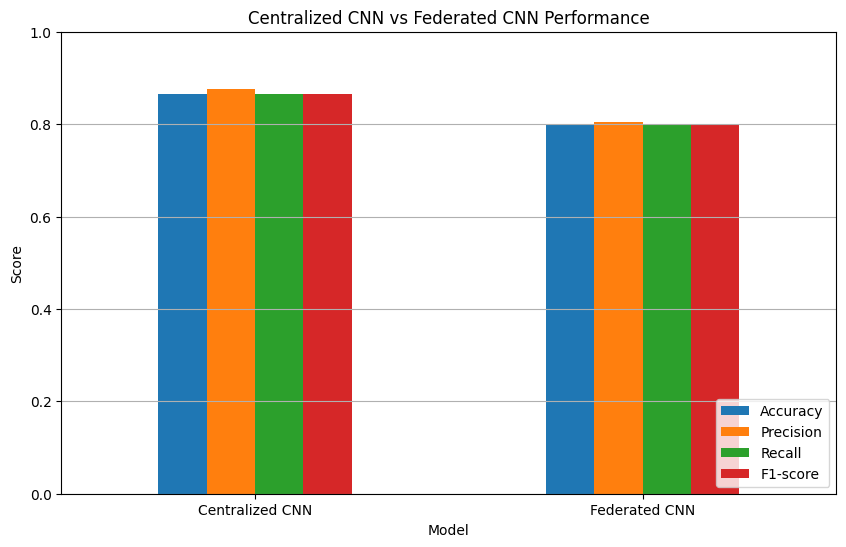

In [ ]:
import matplotlib.pyplot as plt

comparison_df.set_index("Model")[["Accuracy", "Precision", "Recall", "F1-score"]].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Centralized CNN vs Federated CNN Performance")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.grid(axis="y")
plt.legend(loc="lower right")
plt.show()